## Comparing the PCA workflow to Burns' weighted log-odds method

This notebook compares our existing PCA + logistic-regression "speechiness" score (`ccc2026.run_training`/`rolling_samples`) against Burns' weighted log-odds "dialogism" method (`ccc2026.dialogism`), using each method's finished, packaged implementation. See `3 - Burns' dialogism method` for how the dialogism method itself was built and verified.

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import ccc2026
from ccc2026 import dialogism
ccc2026.setup()

tokens = ccc2026.tokens

### Compute the dialogism score

Using the packaged, already-verified implementation (see `3 - Burns' dialogism method`).

In [ ]:
lexicons = dialogism.build_lexicons()
dialogism_score = dialogism.token_dialogism_score(lexicons)
dialogism_score.describe()

### Rolling dialogism score vs. the PCA + logistic regression score

Burns uses a rolling window of 50 tokens for his narrative plot (Figure 9.4); our existing `rolling_samples` defaults to 500. To compare fairly, both methods need to use the *same* window size — so the cell below recomputes the PCA score at each window size tested, rather than reusing a single fixed-window PCA score.

In [5]:
# existing PCA + logistic regression speechiness score, for comparison
feature_set = {
    "lemma": ccc2026.top_lemmas,
    "pos": ccc2026.all_pos,
    "morph": ccc2026.top_morph,
}
train = ccc2026.run_training(feature_set)

In [ ]:
for window in [50, 200, 500, 1000]:
    dialogism_roll = dialogism.rolling_dialogism(dialogism_score, window_size=window)["speech_score"]["score"]

    # PCA score recomputed at the same window, so the comparison is apples-to-apples
    pca_score = ccc2026.rolling_samples(train, window_size=window)["speech_score"]["score"]

    both = pd.DataFrame({"dialogism": dialogism_roll, "pca": pca_score}).dropna()
    print(
        f"window={window}: n={len(both)}, "
        f"pearson r={both['dialogism'].corr(both['pca']):.3f}, "
        f"spearman r={both['dialogism'].corr(both['pca'], method='spearman'):.3f}"
    )

Agreement is strong and stable across window sizes once both methods use the same window (Pearson r &asymp; 0.88&ndash;0.90 from 50 to 1000 tokens) &mdash; confirming the intuition that the two methods are largely measuring the same thing. The scatter plot below uses window=500 as a representative case.

In [ ]:
window = 200
dialogism_roll = dialogism.rolling_dialogism(dialogism_score, window_size=window)["speech_score"]["score"]
pca_score = ccc2026.rolling_samples(train, window_size=window)["speech_score"]["score"]
both = pd.DataFrame({"dialogism": dialogism_roll, "pca": pca_score}).dropna()

g = sns.relplot(data=both, x="pca", y="dialogism", alpha=0.1, height=4)
g.set(
    xlabel="PCA + logistic regression score",
    ylabel="weighted log-odds dialogism score",
    title=f"window={window}",
)
plt.show()

### Overlay for a single book

Both scores standardized (z-scored) so they're visually comparable on one axis, for Iliad 1.

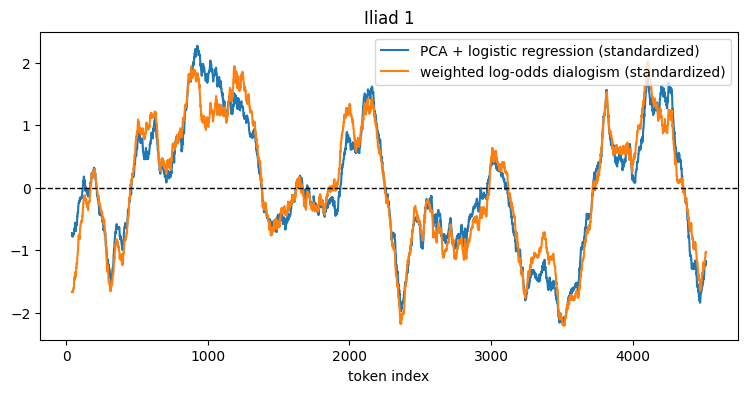

In [19]:
work, pref = "Iliad", "1"
mask = (tokens["work"] == work) & (tokens["pref"] == pref)
idx = tokens.index[mask]

book = pd.DataFrame({
    "dialogism": dialogism_roll.loc[idx],
    "pca": pca_score.reindex(idx),
    "line": tokens.loc[idx, "line"],
}).dropna()

# standardize both scores so they're comparable on one axis
book["dialogism_z"] = (book["dialogism"] - book["dialogism"].mean()) / book["dialogism"].std()
book["pca_z"] = (book["pca"] - book["pca"].mean()) / book["pca"].std()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(book.index, book["pca_z"], label="PCA + logistic regression (standardized)")
ax.plot(book.index, book["dialogism_z"], label="weighted log-odds dialogism (standardized)")
ax.axhline(0, color="k", ls="--", lw=1)
ax.set_title(f"{work} {pref}")
ax.set_xlabel("token index")
ax.legend()
plt.show()